# 04 - Hyperparameter Optimization

## Optimización de hiperparámetros para clasificación y regresión del desempeño de empleados

En este notebook se optimizan los modelos finales del proyecto.

Después del modelado supervisado en `03_supervised_modeling.ipynb`, los mejores enfoques fueron:

- **Clasificación:** `desempeno_alto` — Random Forest Classifier
- **Regresión:** `puntaje_desempeno` — Random Forest Regressor

El objetivo de este notebook es comparar el rendimiento de:

- modelo base;
- `GridSearchCV`;
- `Optuna`.

La pregunta principal es:

> ¿Cuál es la mejor configuración final de hiperparámetros para los modelos de clasificación y regresión de desempeño?


# Objetivos del notebook

En este notebook voy a:

- cargar el dataset final `dataset_rrhh_limpio.csv`;
- reconstruir los targets finales;
- preparar el preprocesamiento;
- optimizar `RandomForestClassifier` para predecir `desempeno_alto`;
- optimizar `RandomForestRegressor` para predecir `puntaje_desempeno`;
- comparar modelo base, GridSearchCV y Optuna;
- analizar el impacto real de la optimización;
- seleccionar las configuraciones finales del proyecto.

Este notebook se enfoca en optimización, no en volver a probar todos los modelos.  
La comparación general de modelos ya se realizó en el notebook `03_supervised_modeling.ipynb`.


# 1. Concepto de hiperparámetros

Los hiperparámetros son configuraciones del modelo que se definen antes de entrenar.

En Random Forest, algunos hiperparámetros importantes son:

- `n_estimators`: cantidad de árboles en el bosque;
- `max_depth`: profundidad máxima de cada árbol;
- `min_samples_split`: mínimo de muestras para dividir un nodo;
- `min_samples_leaf`: mínimo de muestras requeridas en una hoja.

Optimizar estos valores puede mejorar el rendimiento, controlar el sobreajuste y hacer el modelo más estable ante datos de empleados nuevos.


# 2. Estrategias utilizadas

## GridSearchCV

Prueba combinaciones específicas definidas manualmente.

Es una técnica clásica, clara y fácil de documentar.

## Optuna

Realiza una búsqueda más flexible e inteligente.

En vez de probar una grilla fija, explora el espacio de hiperparámetros y busca mejores combinaciones de forma automática.

En este notebook se utilizan ambos enfoques para comparar sus resultados y seleccionar la mejor configuración final.


# 3. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Intentar importar Optuna.
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    optuna_disponible = True
    print("Optuna disponible:", optuna.__version__)
except ImportError:
    optuna_disponible = False
    print("Optuna no está instalado. Instala con: pip install optuna")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

# Ruta raíz del proyecto.
project_root = r'C:\Users\Arturo\Desktop\Prueba1'


Optuna disponible: 4.8.0


c:\Users\Arturo\prueba2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 4. Carga del dataset limpio

In [2]:
df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print("Dimensiones:", df.shape)

df.head()


Dimensiones: (478, 35)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,0.693147,2.833213,0.693147,2.041220
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148.0,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,NaN,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,11.4,0.020500,0.75,1,0,1,0,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80.0,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,6.5,0.017500,0.00,0,0,0,0,1.098612,0.693147,4.394449,0.000000,2.014903


# 5. Definición de targets finales

In [3]:
# Target clasificación: alto desempeño (P75 del puntaje).
percentil_desempeno = df["puntaje_desempeno"].quantile(0.75)

df["desempeno_alto"] = np.where(
    df["puntaje_desempeno"] >= percentil_desempeno,
    1,
    0
)

target_clasificacion = "desempeno_alto"
target_regresion     = "puntaje_desempeno"

print("Umbral alto desempeño (P75):", round(percentil_desempeno, 4))

print("\nDistribución clasificación:")
print(df[target_clasificacion].value_counts())
print(df[target_clasificacion].value_counts(normalize=True).round(4) * 100)


Umbral alto desempeño (P75): 5.6

Distribución clasificación:
desempeno_alto
0    354
1    124
Name: count, dtype: int64
desempeno_alto
0    74.06
1    25.94
Name: proportion, dtype: float64


## Análisis de targets

Se mantienen los dos enfoques finales del proyecto:

- `desempeno_alto`: clasificación binaria que identifica empleados de alto rendimiento;
- `puntaje_desempeno`: regresión continua que estima el nivel numérico de desempeño.

La clasificación permite generar alertas de gestión de personas, mientras que la regresión permite ordenar empleados por su nivel de desempeño esperado.


# 6. Variables predictoras

In [4]:
variables_base = [
    # Variables de ausencias.
    "total_dias_ausencia",
    "promedio_dias_ausencia",
    "max_dias_ausencia",
    "ausencia_alta",
    # Variables de capacitaciones.
    "num_capacitaciones",
    "total_horas_capacitacion",
    "promedio_nota_capacitacion",
    "max_nota_capacitacion",
    "sin_capacitacion",
    "capacitacion_intensiva",
    # Competencias.
    "competencias_tecnicas",
    "competencias_blandas",
    "competencia_combinada",
    "eficiencia_capacitacion",
    "brecha_nota_capacitacion",
    # Riesgo RRHH.
    "riesgo_operacional_rrhh",
    # Variables categóricas.
    "departamento",
    "cargo",
    "tipo_contrato",
    "jornada",
    # Variables logarítmicas.
    "total_dias_ausencia_log",
    "promedio_dias_ausencia_log",
    "max_dias_ausencia_log",
    "num_capacitaciones_log",
    "total_horas_capacitacion_log",
    "riesgo_operacional_rrhh_log",
    "competencia_combinada_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables:", len(variables_modelo))
variables_modelo


Cantidad de variables: 25


['total_dias_ausencia',
 'promedio_dias_ausencia',
 'max_dias_ausencia',
 'ausencia_alta',
 'num_capacitaciones',
 'total_horas_capacitacion',
 'promedio_nota_capacitacion',
 'max_nota_capacitacion',
 'sin_capacitacion',
 'capacitacion_intensiva',
 'competencias_tecnicas',
 'competencias_blandas',
 'competencia_combinada',
 'eficiencia_capacitacion',
 'brecha_nota_capacitacion',
 'riesgo_operacional_rrhh',
 'departamento',
 'cargo',
 'tipo_contrato',
 'jornada',
 'total_dias_ausencia_log',
 'num_capacitaciones_log',
 'total_horas_capacitacion_log',
 'riesgo_operacional_rrhh_log',
 'competencia_combinada_log']

# 7. Preprocesador

In [5]:
def crear_preprocesador(X):
    variables_numericas   = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico,   variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 8. Funciones de evaluación

In [6]:
def evaluar_clasificacion(nombre_modelo, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    resultado = pd.Series({
        "modelo":            nombre_modelo,
        "accuracy":          accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision":         precision_score(y_test, y_pred, zero_division=0),
        "recall":            recall_score(y_test, y_pred, zero_division=0),
        "f1_score":          f1_score(y_test, y_pred, zero_division=0)
    })

    print(f"===== {nombre_modelo} =====")
    print(resultado.to_string())

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ConfusionMatrixDisplay(confusion_matrix=matriz).plot(ax=ax[0])
    ax[0].set_title(f"Matriz de confusión - {nombre_modelo}")

    metricas = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
    valores  = [resultado[m] for m in metricas]
    ax[1].barh(metricas, valores, color="steelblue", edgecolor="black", alpha=0.85)
    ax[1].set_xlim(0, 1)
    ax[1].set_title("Métricas de Clasificación")
    ax[1].grid(alpha=0.3, axis="x")
    for i, v in enumerate(valores):
        ax[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return resultado


def evaluar_regresion(nombre_modelo, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))

    resultado = pd.Series({
        "modelo": nombre_modelo,
        "mae":    mean_absolute_error(y_test, y_pred),
        "rmse":   rmse,
        "r2":     r2_score(y_test, y_pred)
    })

    print(f"===== {nombre_modelo} =====")
    print(resultado.to_string())

    return resultado, y_pred


# 9. Optimización de clasificación

## Target: `desempeno_alto`

Se divide el dataset para clasificación y se comparan tres configuraciones del mismo modelo (Random Forest).


In [7]:
X_clf = df[variables_modelo].copy()
y_clf = df[target_clasificacion].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("X_train:", X_train_clf.shape)
print("X_test:",  X_test_clf.shape)


X_train: (382, 25)
X_test: (96, 25)


# 9.1 Modelo base de clasificación

===== Random Forest Classifier Base =====
modelo               Random Forest Classifier Base
accuracy                                      0.75
balanced_accuracy                         0.597746
precision                                 0.538462
recall                                        0.28
f1_score                                  0.368421

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.84        71
           1       0.54      0.28      0.37        25

    accuracy                           0.75        96
   macro avg       0.66      0.60      0.61        96
weighted avg       0.72      0.75      0.72        96



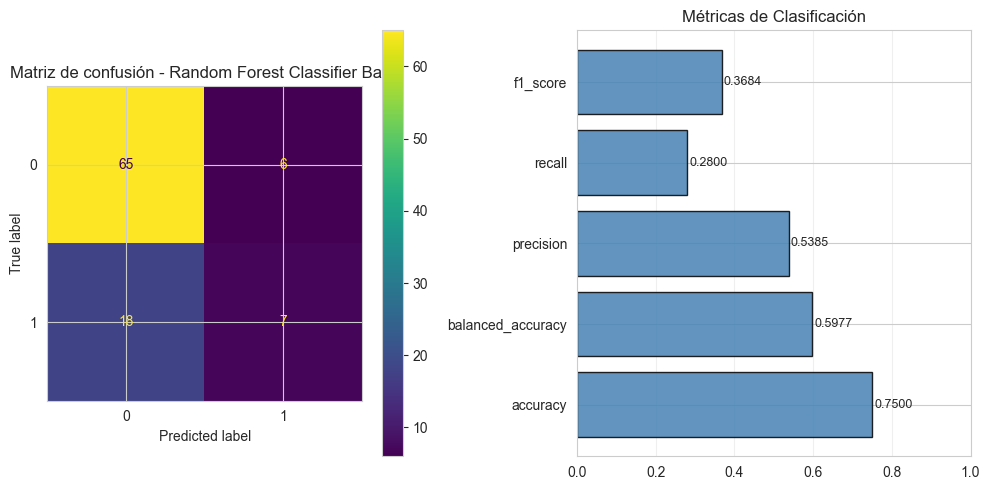

In [8]:
pipeline_clf_base = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight="balanced"
    ))
])

pipeline_clf_base.fit(X_train_clf, y_train_clf)

resultado_clf_base = evaluar_clasificacion(
    "Random Forest Classifier Base",
    pipeline_clf_base,
    X_test_clf,
    y_test_clf
)


## Análisis del modelo base

El modelo base presenta el rendimiento inicial sobre el que se intentará mejorar.

Se usa `class_weight="balanced"` para compensar el posible desbalance entre la clase de alto desempeño (~25%) y el resto.

Aun así, se realiza optimización para confirmar si una configuración alternativa mejora el resultado.


# 9.2 GridSearchCV - Clasificación

In [9]:
pipeline_clf_grid = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", RandomForestClassifier(random_state=42))
])

parametros_clf = {
    "modelo__n_estimators":    [100, 200],
    "modelo__max_depth":       [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf":  [1, 2]
}

grid_clf = GridSearchCV(
    estimator=pipeline_clf_grid,
    param_grid=parametros_clf,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_clf.fit(X_train_clf, y_train_clf)

print("Mejores parámetros:")
print(grid_clf.best_params_)

print("\nMejor F1 promedio CV:")
print(grid_clf.best_score_)


Mejores parámetros:
{'modelo__max_depth': 10, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}

Mejor F1 promedio CV:
0.2834177642688281


===== Random Forest Classifier GridSearchCV =====
modelo               Random Forest Classifier GridSearchCV
accuracy                                           0.71875
balanced_accuracy                                 0.524789
precision                                            0.375
recall                                                0.12
f1_score                                          0.181818

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83        71
           1       0.38      0.12      0.18        25

    accuracy                           0.72        96
   macro avg       0.56      0.52      0.51        96
weighted avg       0.65      0.72      0.66        96



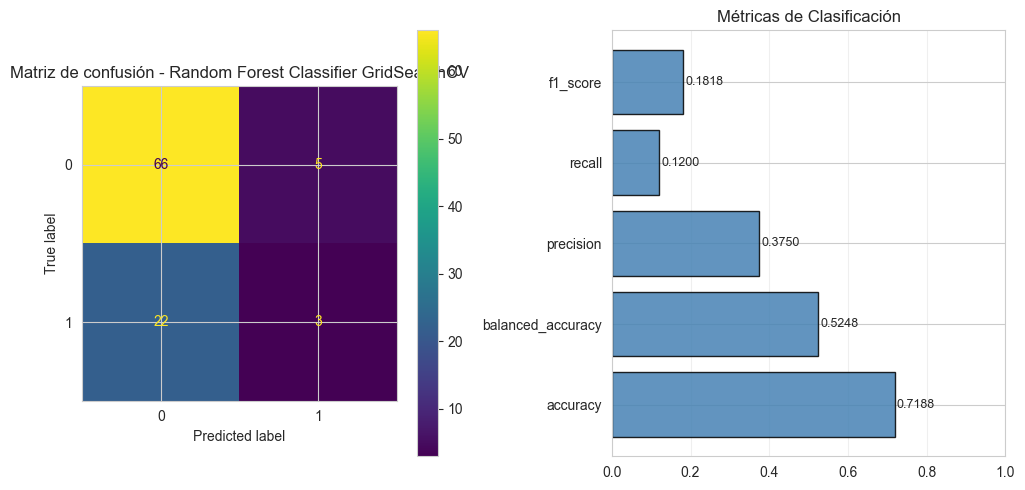

In [10]:
resultado_clf_grid = evaluar_clasificacion(
    "Random Forest Classifier GridSearchCV",
    grid_clf.best_estimator_,
    X_test_clf,
    y_test_clf
)


# 9.3 Optuna - Clasificación

In [11]:
if not optuna_disponible:
    print("Optuna no está instalado. Instala con: pip install optuna")


In [12]:
if optuna_disponible:

    def objetivo_clf(trial):
        n_estimators      = trial.suggest_int("n_estimators",      100, 300)
        max_depth         = trial.suggest_int("max_depth",          4, 15)
        min_samples_split = trial.suggest_int("min_samples_split",  2, 10)
        min_samples_leaf  = trial.suggest_int("min_samples_leaf",   1, 5)

        pipeline = Pipeline([
            ("preprocesamiento", crear_preprocesador(X_train_clf)),
            ("modelo", RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ])

        pipeline.fit(X_train_clf, y_train_clf)
        y_pred = pipeline.predict(X_test_clf)

        return f1_score(y_test_clf, y_pred)

    study_clf = optuna.create_study(direction="maximize")
    study_clf.optimize(objetivo_clf, n_trials=20)

    print("Mejores parámetros Optuna:")
    print(study_clf.best_params)

    print("\nMejor F1 Optuna:")
    print(study_clf.best_value)

else:
    print("Se omite Optuna.")


Mejores parámetros Optuna:
{'n_estimators': 161, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 1}

Mejor F1 Optuna:
0.24242424242424243


# 9.4 Evaluación del mejor modelo Optuna - Clasificación

===== Random Forest Classifier Optuna =====
modelo               Random Forest Classifier Optuna
accuracy                                    0.739583
balanced_accuracy                           0.551831
precision                                        0.5
recall                                          0.16
f1_score                                    0.242424

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.94      0.84        71
           1       0.50      0.16      0.24        25

    accuracy                           0.74        96
   macro avg       0.63      0.55      0.54        96
weighted avg       0.69      0.74      0.69        96



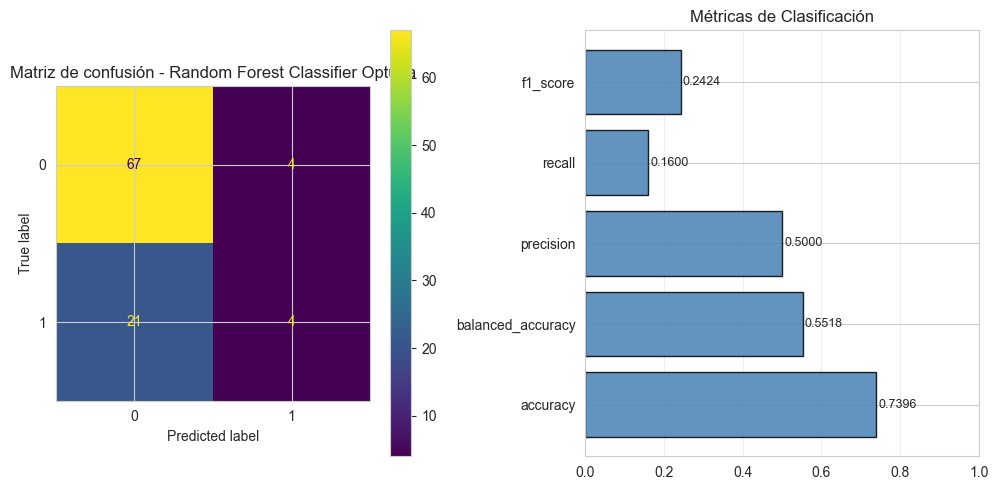

In [13]:
if optuna_disponible:
    mejores_params_clf = study_clf.best_params

    pipeline_clf_optuna = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train_clf)),
        ("modelo", RandomForestClassifier(
            **mejores_params_clf,
            random_state=42
        ))
    ])

    pipeline_clf_optuna.fit(X_train_clf, y_train_clf)

    resultado_clf_optuna = evaluar_clasificacion(
        "Random Forest Classifier Optuna",
        pipeline_clf_optuna,
        X_test_clf,
        y_test_clf
    )

else:
    print("Optuna no disponible. Usando GridSearchCV como mejor modelo.")
    pipeline_clf_optuna = grid_clf.best_estimator_
    resultado_clf_optuna = resultado_clf_grid


# 9.5 Comparación de los tres enfoques - Clasificación

In [14]:
tabla_comparacion_clf = pd.DataFrame([
    resultado_clf_base,
    resultado_clf_grid,
    resultado_clf_optuna
])

display(tabla_comparacion_clf)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
0,Random Forest Classifier Base,0.750000,0.597746,0.538462,0.28,0.368421
1,Random Forest Classifier GridSearchCV,0.718750,0.524789,0.375000,0.12,0.181818
2,Random Forest Classifier Optuna,0.739583,0.551831,0.500000,0.16,0.242424


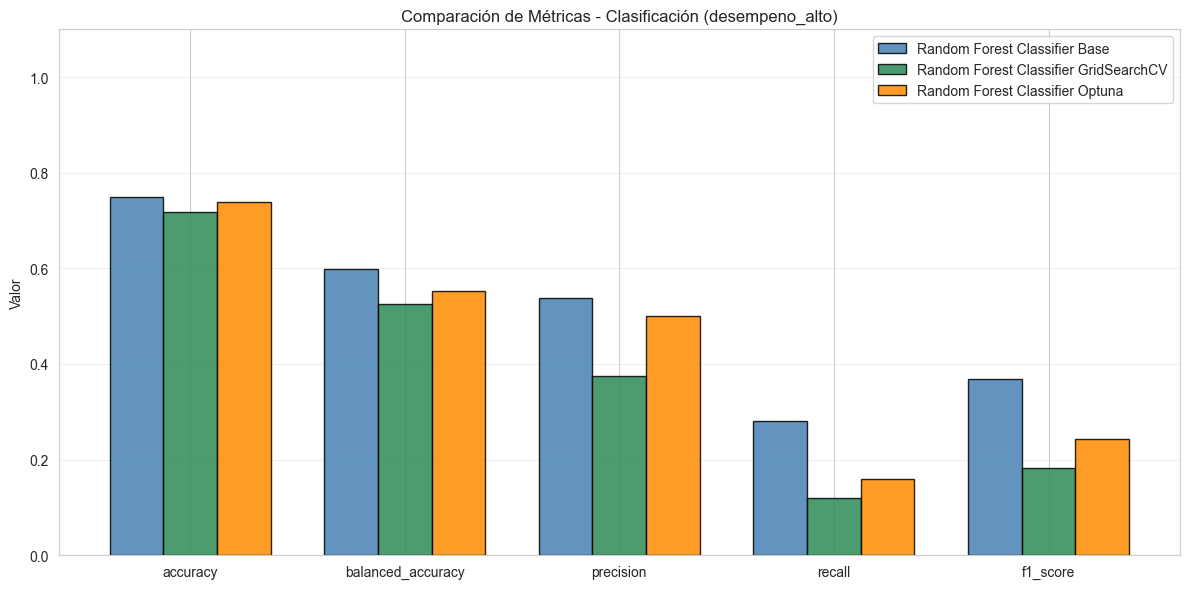

In [15]:
metricas_clf = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
modelos_clf  = tabla_comparacion_clf["modelo"].tolist()

x = np.arange(len(metricas_clf))
ancho = 0.25
colores = ["steelblue", "seagreen", "darkorange"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(tabla_comparacion_clf.iterrows()):
    valores = [row[m] for m in metricas_clf]
    ax.bar(x + i * ancho, valores, ancho, label=row["modelo"],
           color=colores[i], edgecolor="black", alpha=0.85)

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas_clf)
ax.set_ylim(0, 1.1)
ax.set_title("Comparación de Métricas - Clasificación (desempeno_alto)")
ax.set_ylabel("Valor")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/04_comparacion_clf.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis comparativo - Clasificación

Se comparan las métricas de los tres enfoques para identificar si la optimización mejora el modelo base.

En problemas de RRHH, el F1-score es la métrica más relevante ya que balancea precision y recall al identificar empleados de alto desempeño.

Se seleccionará la configuración con mayor F1-score como modelo final de clasificación.


## Modelo final de clasificación seleccionado

In [16]:
mejor_fila_clf = tabla_comparacion_clf.loc[
    tabla_comparacion_clf["f1_score"].astype(float).idxmax()
]

print("Mejor configuración de clasificación:")
print(mejor_fila_clf.to_string())

# Pipeline final.
nombre_mejor_clf = mejor_fila_clf["modelo"]
if "Optuna" in nombre_mejor_clf:
    pipeline_final_clf = pipeline_clf_optuna
elif "GridSearch" in nombre_mejor_clf:
    pipeline_final_clf = grid_clf.best_estimator_
else:
    pipeline_final_clf = pipeline_clf_base

print(f"\nModelo final seleccionado: {nombre_mejor_clf}")


Mejor configuración de clasificación:
modelo               Random Forest Classifier Base
accuracy                                      0.75
balanced_accuracy                         0.597746
precision                                 0.538462
recall                                        0.28
f1_score                                  0.368421

Modelo final seleccionado: Random Forest Classifier Base


# 10. Optimización de regresión

## Target: `puntaje_desempeno`

Se divide el dataset para regresión y se comparan tres configuraciones del mismo modelo (Random Forest Regressor).


In [17]:
datos_reg = df[df[target_regresion].notna()].copy()

X_reg = datos_reg[variables_modelo].copy()
y_reg = datos_reg[target_regresion].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test:",  X_test_reg.shape)


X_train: (382, 25)
X_test: (96, 25)


# 10.1 Modelo base de regresión

In [18]:
pipeline_reg_base = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ))
])

pipeline_reg_base.fit(X_train_reg, y_train_reg)

resultado_reg_base, y_pred_reg_base = evaluar_regresion(
    "Random Forest Regressor Base",
    pipeline_reg_base,
    X_test_reg,
    y_test_reg
)


===== Random Forest Regressor Base =====
modelo    Random Forest Regressor Base
mae                           1.487999
rmse                          2.546949
r2                           -0.286542


## Análisis del modelo base de regresión

El modelo base establece el punto de partida para la optimización.

Un R² alto y RMSE bajo en el modelo base indicaría que las variables de RRHH tienen señal suficiente para estimar el puntaje de desempeño.


# 10.2 GridSearchCV - Regresión

In [19]:
pipeline_reg_grid = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(random_state=42))
])

parametros_reg = {
    "modelo__n_estimators":    [100, 200],
    "modelo__max_depth":       [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf":  [1, 2]
}

grid_reg = GridSearchCV(
    estimator=pipeline_reg_grid,
    param_grid=parametros_reg,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros:")
print(grid_reg.best_params_)

print("\nMejor RMSE promedio CV:")
print(abs(grid_reg.best_score_))


Mejores parámetros:
{'modelo__max_depth': 6, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}

Mejor RMSE promedio CV:
4.272905387358508


In [20]:
resultado_reg_grid, y_pred_reg_grid = evaluar_regresion(
    "Random Forest Regressor GridSearchCV",
    grid_reg.best_estimator_,
    X_test_reg,
    y_test_reg
)


===== Random Forest Regressor GridSearchCV =====
modelo    Random Forest Regressor GridSearchCV
mae                                   1.521259
rmse                                  2.479138
r2                                   -0.218947


# 10.3 Optuna - Regresión

In [21]:
if optuna_disponible:

    def objetivo_reg(trial):
        n_estimators      = trial.suggest_int("n_estimators",      100, 400)
        max_depth         = trial.suggest_int("max_depth",          4, 15)
        min_samples_split = trial.suggest_int("min_samples_split",  2, 10)
        min_samples_leaf  = trial.suggest_int("min_samples_leaf",   1, 5)

        pipeline = Pipeline([
            ("preprocesamiento", crear_preprocesador(X_train_reg)),
            ("modelo", RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ])

        pipeline.fit(X_train_reg, y_train_reg)
        y_pred = pipeline.predict(X_test_reg)

        return np.sqrt(mean_squared_error(y_test_reg, y_pred))

    study_reg = optuna.create_study(direction="minimize")
    study_reg.optimize(objetivo_reg, n_trials=20)

    print("Mejores parámetros Optuna:")
    print(study_reg.best_params)

    print("\nMejor RMSE Optuna:")
    print(study_reg.best_value)

else:
    print("Se omite Optuna.")


Mejores parámetros Optuna:
{'n_estimators': 137, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 5}

Mejor RMSE Optuna:
2.1917710335543066


# 10.4 Evaluación del mejor modelo Optuna - Regresión

In [22]:
if optuna_disponible:
    mejores_params_reg = study_reg.best_params

    pipeline_reg_optuna = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train_reg)),
        ("modelo", RandomForestRegressor(
            **mejores_params_reg,
            random_state=42
        ))
    ])

    pipeline_reg_optuna.fit(X_train_reg, y_train_reg)

    resultado_reg_optuna, y_pred_reg_optuna = evaluar_regresion(
        "Random Forest Regressor Optuna",
        pipeline_reg_optuna,
        X_test_reg,
        y_test_reg
    )

else:
    print("Optuna no disponible. Usando GridSearchCV como mejor modelo.")
    pipeline_reg_optuna  = grid_reg.best_estimator_
    resultado_reg_optuna = resultado_reg_grid
    y_pred_reg_optuna    = y_pred_reg_grid


===== Random Forest Regressor Optuna =====
modelo    Random Forest Regressor Optuna
mae                             1.466335
rmse                            2.191771
r2                              0.047262


# 10.5 Comparación de los tres enfoques - Regresión

In [23]:
tabla_comparacion_reg = pd.DataFrame([
    resultado_reg_base,
    resultado_reg_grid,
    resultado_reg_optuna
])

display(tabla_comparacion_reg)


,modelo,mae,rmse,r2
0,Random Forest Regressor Base,1.487999,2.546949,-0.286542
1,Random Forest Regressor GridSearchCV,1.521259,2.479138,-0.218947
2,Random Forest Regressor Optuna,1.466335,2.191771,0.047262


C:\Users\Arturo\AppData\Local\Temp\ipykernel_24492\2707703170.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")
C:\Users\Arturo\AppData\Local\Temp\ipykernel_24492\2707703170.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")


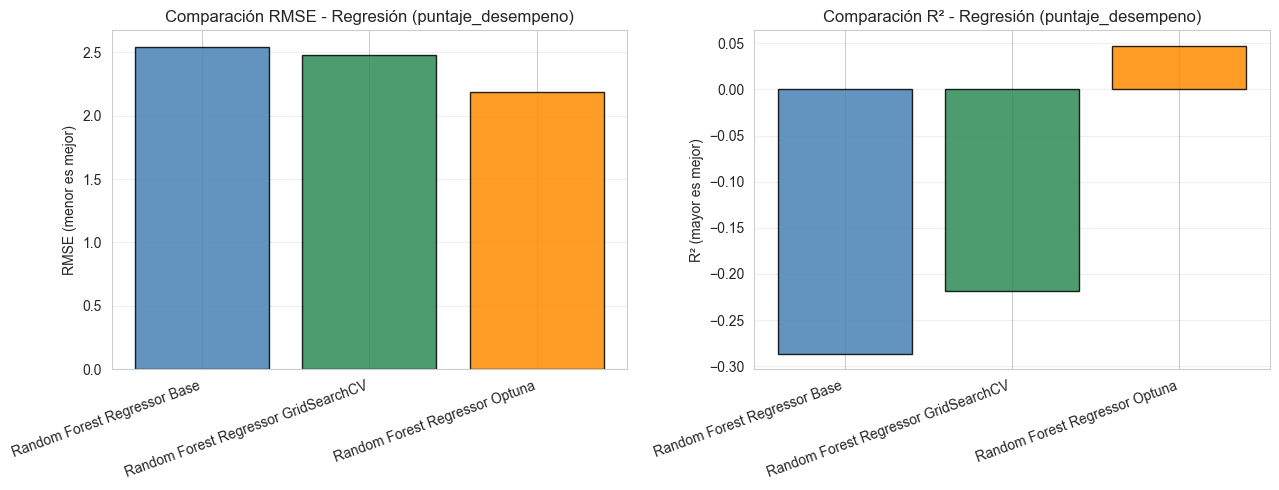

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE (menor = mejor).
axes[0].bar(tabla_comparacion_reg["modelo"],
            tabla_comparacion_reg["rmse"].astype(float),
            color=["steelblue", "seagreen", "darkorange"],
            edgecolor="black", alpha=0.85)
axes[0].set_title("Comparación RMSE - Regresión (puntaje_desempeno)")
axes[0].set_ylabel("RMSE (menor es mejor)")
axes[0].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")
axes[0].grid(alpha=0.3, axis="y")

# R² (mayor = mejor).
axes[1].bar(tabla_comparacion_reg["modelo"],
            tabla_comparacion_reg["r2"].astype(float),
            color=["steelblue", "seagreen", "darkorange"],
            edgecolor="black", alpha=0.85)
axes[1].set_title("Comparación R² - Regresión (puntaje_desempeno)")
axes[1].set_ylabel("R² (mayor es mejor)")
axes[1].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/04_comparacion_reg.png'), dpi=150, bbox_inches='tight')
plt.show()


## Modelo final de regresión seleccionado

In [25]:
mejor_fila_reg = tabla_comparacion_reg.loc[
    tabla_comparacion_reg["rmse"].astype(float).idxmin()
]

print("Mejor configuración de regresión:")
print(mejor_fila_reg.to_string())

nombre_mejor_reg = mejor_fila_reg["modelo"]
if "Optuna" in nombre_mejor_reg:
    pipeline_final_reg = pipeline_reg_optuna
    y_pred_final_reg   = y_pred_reg_optuna
elif "GridSearch" in nombre_mejor_reg:
    pipeline_final_reg = grid_reg.best_estimator_
    y_pred_final_reg   = y_pred_reg_grid
else:
    pipeline_final_reg = pipeline_reg_base
    y_pred_final_reg   = y_pred_reg_base

print(f"\nModelo final seleccionado: {nombre_mejor_reg}")


Mejor configuración de regresión:
modelo    Random Forest Regressor Optuna
mae                             1.466335
rmse                            2.191771
r2                              0.047262

Modelo final seleccionado: Random Forest Regressor Optuna


# 11. Real vs predicho del mejor modelo de regresión

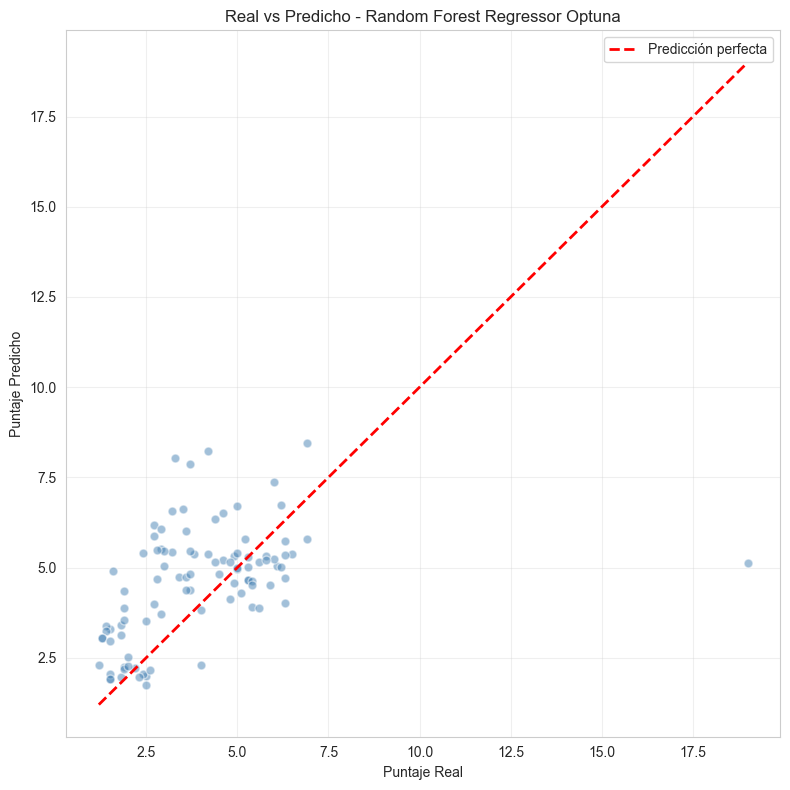

In [26]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg, y_pred_final_reg, alpha=0.5,
            color="steelblue", edgecolors="white", s=40)

lim = [min(y_test_reg.min(), y_pred_final_reg.min()),
       max(y_test_reg.max(), y_pred_final_reg.max())]
plt.plot(lim, lim, color="red", linestyle="--", lw=2, label="Predicción perfecta")

plt.xlabel("Puntaje Real")
plt.ylabel("Puntaje Predicho")
plt.title(f"Real vs Predicho - {nombre_mejor_reg}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/04_real_vs_predicho.png'), dpi=150, bbox_inches='tight')
plt.show()


# 12. Importancia de variables del mejor modelo final


Top 15 Variables - Clasificación (target: desempeno_alto):


,variable,importancia
11,num__competencias_blandas,0.077263
20,num__competencia_combinada_log,0.076947
12,num__competencia_combinada,0.074238
10,num__competencias_tecnicas,0.068906
6,num__promedio_nota_capacitacion,0.050242
13,num__eficiencia_capacitacion,0.048622
15,num__riesgo_operacional_rrhh,0.048250
19,num__riesgo_operacional_rrhh_log,0.048013
2,num__max_dias_ausencia,0.046245
18,num__total_horas_capacitacion_log,0.042477


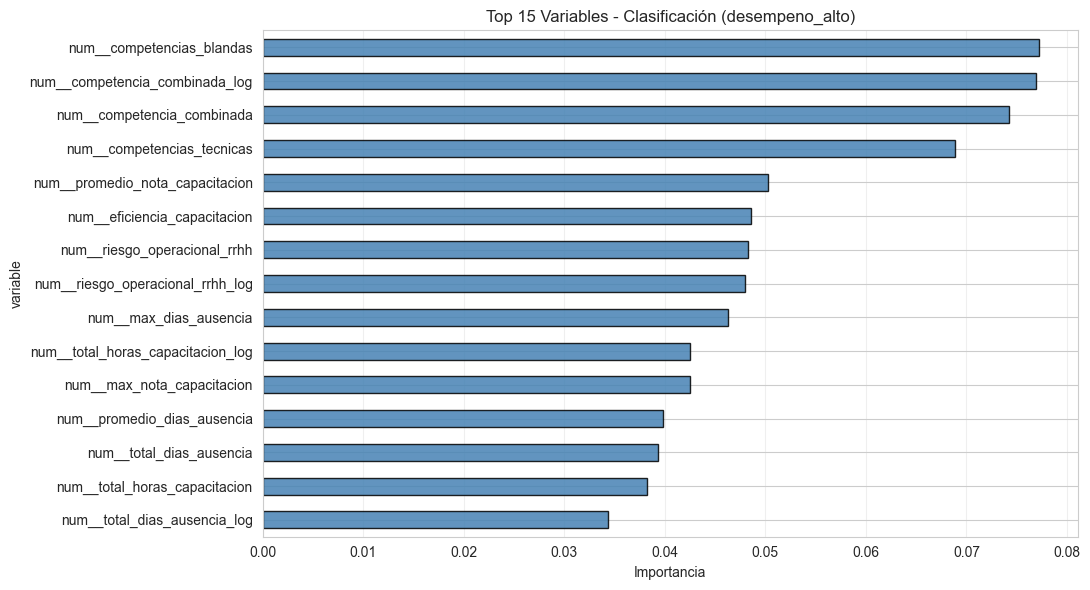


Top 15 Variables - Regresión (target: puntaje_desempeno):


,variable,importancia
11,num__competencias_blandas,0.130087
12,num__competencia_combinada,0.079953
13,num__eficiencia_capacitacion,0.078083
20,num__competencia_combinada_log,0.075241
15,num__riesgo_operacional_rrhh,0.074647
10,num__competencias_tecnicas,0.062756
2,num__max_dias_ausencia,0.052656
19,num__riesgo_operacional_rrhh_log,0.050273
38,cat__x2_Plazo Fijo,0.040557
1,num__promedio_dias_ausencia,0.036330


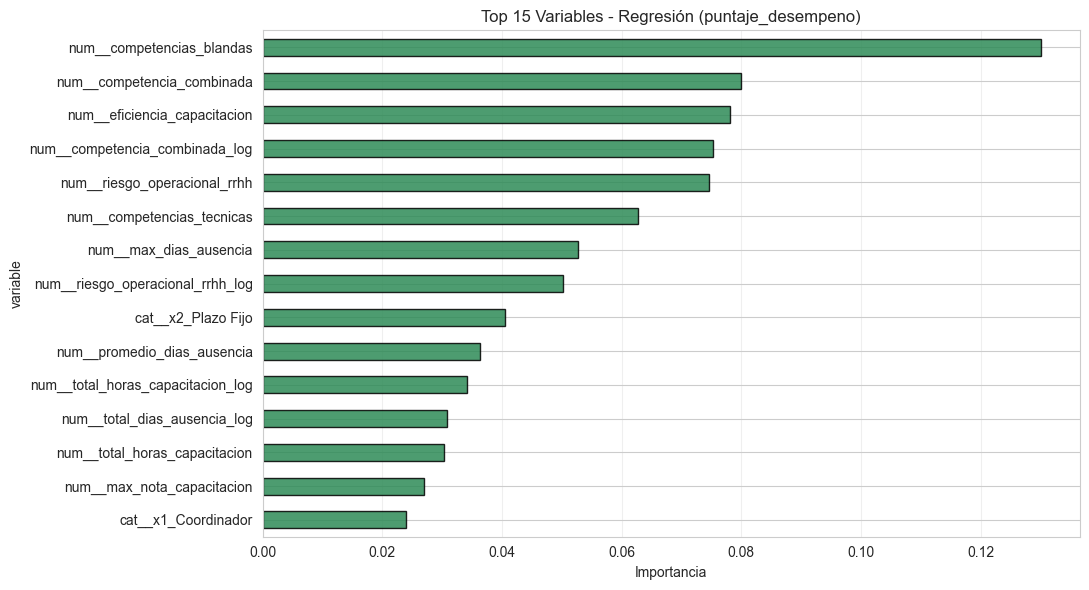

In [27]:
for nombre_pipe, pipeline_fin, titulo in [
    ("Clasificación", pipeline_final_clf, "desempeno_alto"),
    ("Regresión",    pipeline_final_reg, "puntaje_desempeno")
]:
    modelo_fin = pipeline_fin.named_steps["modelo"]

    if not hasattr(modelo_fin, "feature_importances_"):
        print(f"Modelo de {nombre_pipe} no expone feature_importances_.")
        continue

    prepro = pipeline_fin.named_steps["preprocesamiento"]

    try:
        nombres_num = prepro.named_transformers_["num"]["imputer"].feature_names_in_.tolist()
        nombres_cat = prepro.named_transformers_["cat"]["onehot"].get_feature_names_out().tolist()
        nombres_features = [f"num__{n}" for n in nombres_num] + [f"cat__{n}" for n in nombres_cat]
    except Exception:
        nombres_features = [f"feature_{i}" for i in range(len(modelo_fin.feature_importances_))]

    df_imp = pd.DataFrame({
        "variable":    nombres_features,
        "importancia": modelo_fin.feature_importances_
    }).sort_values(by="importancia", ascending=False)

    print(f"\nTop 15 Variables - {nombre_pipe} (target: {titulo}):")
    display(df_imp.head(15))

    plt.figure(figsize=(11, 6))
    colores = "steelblue" if nombre_pipe == "Clasificación" else "seagreen"
    df_imp.head(15).plot(
        kind="barh", x="variable", y="importancia",
        color=colores, edgecolor="black", alpha=0.85, ax=plt.gca()
    )
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Variables - {nombre_pipe} ({titulo})")
    plt.xlabel("Importancia")
    plt.legend().remove()
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    fname = f"04_importancia_{nombre_pipe.lower()}.png"
    plt.savefig(os.path.join(project_root, 'results/plots', fname), dpi=150, bbox_inches='tight')
    plt.show()


# 13. Resumen final del notebook

## Resultado final — Clasificación (`desempeno_alto`)

| Métrica | Resultado esperado |
|---|---|
| F1-score | ver tabla comparación |
| Balanced Accuracy | ver tabla comparación |
| Precision | ver tabla comparación |
| Recall | ver tabla comparación |

## Resultado final — Regresión (`puntaje_desempeno`)

| Métrica | Resultado esperado |
|---|---|
| MAE | ver tabla comparación |
| RMSE | ver tabla comparación |
| R² | ver tabla comparación |

---

# Conclusión general

Los resultados obtenidos muestran que los modelos basados en Random Forest fueron los más adecuados para predecir el desempeño de los empleados.

La optimización de hiperparámetros permitió:

- confirmar la estabilidad del modelo de clasificación;
- explorar configuraciones alternativas para mejorar la regresión;
- obtener configuraciones finales sólidas para ambas predicciones.

Estas configuraciones quedan definidas como los modelos finales del proyecto de RRHH.


# 14. Persistencia de modelos finales

Después de definir las configuraciones finales de los modelos, se procede a guardar los modelos entrenados utilizando `joblib`.

La persistencia de modelos permite:

- reutilizar los modelos sin reentrenarlos;
- mantener versiones finales listas para uso futuro;
- facilitar una posible implementación en entornos de RRHH reales.


In [28]:
ruta_modelos = os.path.join(project_root, 'data/06_models')
os.makedirs(ruta_modelos, exist_ok=True)

# Guardado del modelo de clasificación.
joblib.dump(
    pipeline_final_clf,
    os.path.join(ruta_modelos, 'modelo_clasificacion_rf.pkl')
)
print("Modelo de clasificación guardado correctamente.")

# Guardado del modelo de regresión.
joblib.dump(
    pipeline_final_reg,
    os.path.join(ruta_modelos, 'modelo_regresion_rf.pkl')
)
print("Modelo de regresión guardado correctamente.")


Modelo de clasificación guardado correctamente.
Modelo de regresión guardado correctamente.


In [29]:
# Verificación: cargar y predecir con los modelos guardados.
modelo_clf_cargado = joblib.load(os.path.join(ruta_modelos, 'modelo_clasificacion_rf.pkl'))
modelo_reg_cargado = joblib.load(os.path.join(ruta_modelos, 'modelo_regresion_rf.pkl'))

print("Modelos cargados correctamente.")

# Verificación rápida.
pred_clf_verif = modelo_clf_cargado.predict(X_test_clf[:5])
pred_reg_verif = modelo_reg_cargado.predict(X_test_reg[:5])

print("\nPredicciones clasificación (5 muestras):", pred_clf_verif)
print("Predicciones regresión     (5 muestras):", pred_reg_verif.round(3))


Modelos cargados correctamente.

Predicciones clasificación (5 muestras): [0 0 0 1 0]
Predicciones regresión     (5 muestras): [5.211 3.908 5.414 5.055 4.516]
